In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB

In [2]:
dx = 0.001
shifts = np.array([0., 
                   0.001, 0.001 + 0.1 * dx, 
                   0.01, 0.01 + dx, 
                   0.05, 0.05 + dx,
                   0.1, 0.1 + dx,
                   0.158, 0.159 + dx,
                   0.251, 0.251 + dx,
                   0.398, 0.398 + dx,
                   0.631, 0.631 + dx,
                   1., 1. + dx])
num_shifts = len(shifts)

In [3]:
# load shared library
lTDB = pyJHTDB.libJHTDB()
#initialize webservices
lTDB.initialize()

#Add token
auth_token  = "edu.jhu.pha.turbulence.testing-201311"  #Replace with your own token here
lTDB.add_token(auth_token)

In [4]:
num_points = 10
data = np.zeros((num_points, num_shifts))

In [5]:
point = np.zeros((num_shifts, 3), dtype = np.float32)
velocity = np.zeros((num_shifts, 3), dtype = np.float32)

In [6]:
for k in range(num_points):
    # Рандомим точку
    point[0] = np.random.uniform(-2. * np.pi, 2. * np.pi, 3)
    # Заполняем сдвиги
    for j in range(1, num_shifts):
        point[j] = point[0] + np.array([shifts[j], 0., 0.], dtype=np.float32)
    # Берем скорость в выбранных точках
    velocity = lTDB.getData(
        0.1,
        point,
        data_set='isotropic1024coarse',
        sinterp = 4,
        getFunction='getVelocity')
    data[k] = velocity[:, 0]

In [7]:
np.shape(data)

(10, 19)

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time

# Параметры
dx = 0.001
shifts = np.array([0., 
                   0.001, 0.001 + 0.1 * dx, 
                   0.01, 0.01 + dx, 
                   0.05, 0.05 + dx,
                   0.1, 0.1 + dx,
                   0.158, 0.159 + dx,
                   0.251, 0.251 + dx,
                   0.398, 0.398 + dx,
                   0.631, 0.631 + dx,
                   1., 1. + dx])
num_shifts = len(shifts)
num_points = 100

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание массива для данных
data = np.zeros((num_points, num_shifts))

# Сбор данных
start_time = time.time()
for k in range(num_points):
    try:
        # Рандомим точку
        point = np.zeros((num_shifts, 3), dtype=np.float32)
        point[0] = np.random.uniform(-2. * np.pi, 2. * np.pi, 3)
        
        # Заполняем сдвиги
        for j in range(1, num_shifts):
            point[j] = point[0] + np.array([shifts[j], 0., 0.], dtype=np.float32)
        
        # Берем скорость в выбранных точках
        velocity = lTDB.getData(
            0.1,
            point,
            data_set='isotropic1024coarse',
            sinterp=4,
            getFunction='getVelocity'
        )
        data[k] = velocity[:, 0]
    except Exception as e:
        print(f"Error retrieving data for point {k}: {e}")
        continue

end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")

# Сохранение данных
np.save('velocity_data.npy', data)

# Визуализация данных
plt.figure(figsize=(10, 6))
for k in range(num_points):
    plt.plot(shifts, data[k], alpha=0.5)
plt.xlabel('Shift')
plt.ylabel('Velocity in X-direction')
plt.title('Velocity Profile for Different Shifts')
plt.savefig('velocity_profile.png')
plt.show()

# Завершение работы с JHTDB
lTDB.finalize()

: 

In [1]:
np.shape(data)

NameError: name 'np' is not defined

Collected 2 points out of 10
Collected 4 points out of 10
Collected 6 points out of 10
Collected 8 points out of 10
Collected 10 points out of 10
Data collection completed in 4.93 seconds.
Total collected points: 10


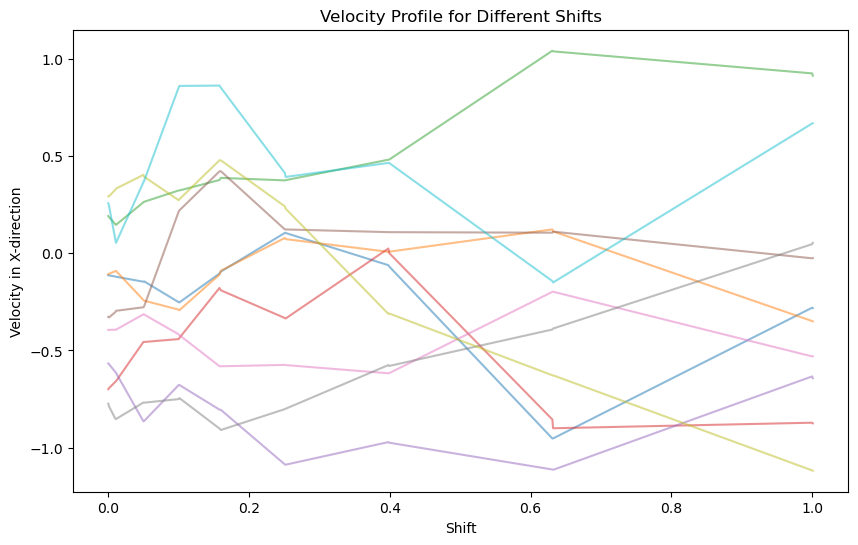

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time

# Параметры
dx = 0.001
shifts = np.array([0., 
                   0.001, 0.001 + 0.1 * dx, 
                   0.01, 0.01 + dx, 
                   0.05, 0.05 + dx,
                   0.1, 0.1 + dx,
                   0.158, 0.159 + dx,
                   0.251, 0.251 + dx,
                   0.398, 0.398 + dx,
                   0.631, 0.631 + dx,
                   1., 1. + dx])
num_shifts = len(shifts)
num_points = 10

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание массива для данных
data = np.zeros((num_points, num_shifts))

# Сбор данных
start_time = time.time()
collected_points = 0

for k in range(num_points):
    try:
        # Рандомим точку
        point = np.zeros((num_shifts, 3), dtype=np.float32)
        point[0] = np.random.uniform(-2. * np.pi, 2. * np.pi, 3)
        
        # Заполняем сдвиги
        for j in range(1, num_shifts):
            point[j] = point[0] + np.array([shifts[j], 0., 0.], dtype=np.float32)
        
        # Берем скорость в выбранных точках
        velocity = lTDB.getData(
            0.1,
            point,
            data_set='isotropic1024coarse',
            sinterp=4,
            getFunction='getVelocity'
        )
        data[k] = velocity[:, 0]
        collected_points += 1
        
        # Вывод промежуточного счетчика
        if (k + 1) % 2 == 0:
            print(f"Collected {collected_points} points out of {num_points}")
    except Exception as e:
        print(f"Error retrieving data for point {k}: {e}")
        continue

end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Сохранение данных
np.save('velocity_data.npy', data)

# Визуализация данных
plt.figure(figsize=(10, 6))
for k in range(num_points):
    plt.plot(shifts, data[k], alpha=0.5)
plt.xlabel('Shift')
plt.ylabel('Velocity in X-direction')
plt.title('Velocity Profile for Different Shifts')
plt.savefig('velocity_profile.png')
plt.show()

In [ ]:
import numpy as np
import pyJHTDB
import time

# Параметры
dx = 0.001
shifts = np.array([0., 
                  # 0.001, 0.001 + 0.1 * dx, 
                  # 0.01, 0.01 + dx, 
                  # 0.05, 0.05 + dx,
                  # 0.1, 0.1 + dx,
                  # 0.158, 0.159 + dx,
                   0.251, 0.251 + dx#,
                  # 0.398, 0.398 + dx,
                  # 0.631, 0.631 + dx,
                  # 1., 1. + dx
                  ])
num_shifts = len(shifts)
num_points = 20

# Временные сдвиги
time_shifts = np.array([0, 0.03, 0.05, 0.06, 0.09
                        , 0.1, 0.15, 0.3, 0.4, 0.5
                        #, 0.6, 0.8, 0.9, 1, 1.2, 1.5, 1.75, 2, 2.5, 3.5, 4, 5
                        ])
num_time_shifts = len(time_shifts)

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание массива для данных
data = np.zeros((num_points, num_shifts, num_time_shifts))

# Сбор данных
start_time = time.time()
collected_points = 0

for k in range(num_points):
    try:
        # Рандомим точку
        point = np.zeros((num_shifts, 3), dtype=np.float32)
        point[0] = np.random.uniform(-2. * np.pi, 2. * np.pi, 3)
        
        # Заполняем сдвиги
        for j in range(1, num_shifts):
            point[j] = point[0] + np.array([shifts[j], 0., 0.], dtype=np.float32)
        
        # Берем скорость в выбранных точках для каждого момента времени
        for t in range(num_time_shifts):
            velocity = lTDB.getData(
                4.024 + time_shifts[t],  # Указание времени
                point,
                data_set='isotropic1024coarse',
                sinterp=4,
                getFunction='getVelocity'
            )
            data[k, :, t] = velocity[:, 0]
        
        collected_points += 1
        
        # Вывод промежуточного счетчика
        if (k + 1) % 2 == 0:
            print(f"Collected {collected_points} points out of {num_points}")
    except Exception as e:
        print(f"Error retrieving data for point {k}: {e}")
        continue

end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

Collected 2 points out of 20
Collected 4 points out of 20
Collected 6 points out of 20
Collected 8 points out of 20
Collected 10 points out of 20
Collected 12 points out of 20
Collected 14 points out of 20
Collected 16 points out of 20
Collected 18 points out of 20
Collected 20 points out of 20
Data collection completed in 133.16 seconds.
Total collected points: 20


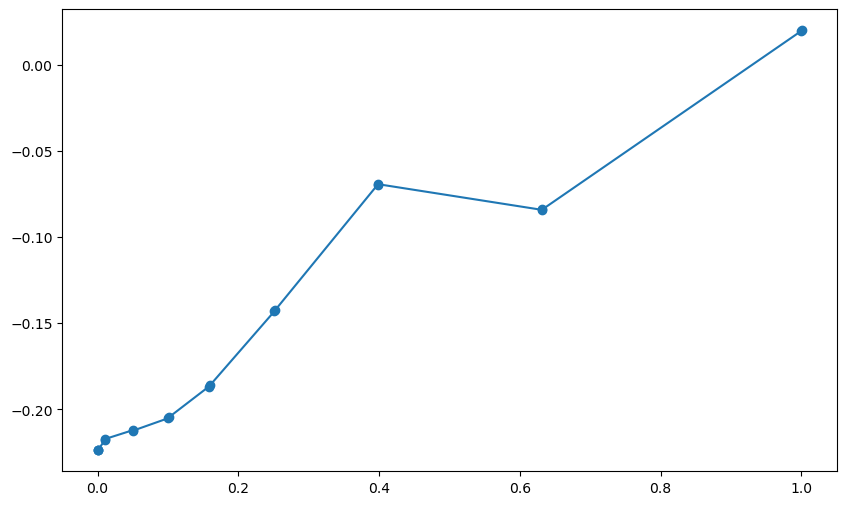

In [4]:
import matplotlib.pyplot as plt

# Расчет средних значений скорости по всем точкам для каждого временного сдвига
mean_velocities = np.mean(data, axis=(0, 2))

# Визуализация средних значений скорости
plt.figure(figsize=(10, 6))
plt.plot(shifts, mean_velocities, marker='o')

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 3  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 3  # 100  # 100  # 800
Nmb_of_Widths = 3  # 15
Nmb_of_TimeSteps = 6
Width = 0.1  # \eta=0.0028, L=1.364, \lambda=0.113, x\in(0,2\pi), 1024^3
Width2 = 0.4
time_0 = 0.2  # t\in(0; 10.056), \delta t=0.002, 5028 snapshots
time_step = 0.03  # t_\eta=0.0424, t_L=1.99

# Временные сдвиги
time_shifts = np.arange(0, 3 * Nmb_of_TimeSteps + 1)
delta_t = time_shifts * time_step

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((4, 4, Nmb_of_pts_1cycle))
    s[1, 1, :] = np.sin(Theta) * np.cos(Phi)
    s[1, 2, :] = np.sin(Theta) * np.sin(Phi)
    s[1, 3, :] = np.cos(Theta)
    s[2, 1, :] = np.cos(Theta) * np.cos(Phi)
    s[2, 2, :] = np.cos(Theta) * np.sin(Phi)
    s[2, 3, :] = -np.sin(Theta)
    s[3, 1, :] = -np.sin(Phi)
    s[3, 2, :] = np.cos(Phi)
    s[3, 3, :] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths + 1, 3))
    points21 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths + 1, 3))

    for I_W in range(Nmb_of_Widths + 1):
        points2[:, I_W, :] = points + I_W * Width * s[1, :, :].T
        points21[:, I_W, :] = points + (I_W + 1) * Width2 * s[1, :, :].T

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths + 1, 3 * Nmb_of_TimeSteps + 1, 3))
    Veloc21 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths + 1, 3 * Nmb_of_TimeSteps + 1, 3))
    VelGr2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths + 1, 3 * Nmb_of_TimeSteps + 1, 3, 3))
    VelGr21 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths + 1, 3 * Nmb_of_TimeSteps + 1, 3, 3))

    for I_T in range(3 * Nmb_of_TimeSteps + 1):
        for I_W in range(Nmb_of_Widths + 1):
            points3 = points2[:, I_W, :]
            points31 = points21[:, I_W, :]

            Veloc3 = lTDB.getData(
                time_0 + delta_t[I_T],
                points3.astype(np.float32),
                data_set='isotropic1024',
                sinterp=4,
                getFunction='getVelocity'
            )
            VelGr3 = lTDB.getData(
                time_0 + delta_t[I_T],
                points3.astype(np.float32),
                data_set='isotropic1024',
                sinterp=4,
                getFunction='getVelocityGradient'
            )
            Veloc31 = lTDB.getData(
                time_0 + delta_t[I_T],
                points31.astype(np.float32),
                data_set='isotropic1024',
                sinterp=4,
                getFunction='getVelocity'
            )
            VelGr31 = lTDB.getData(
                time_0 + delta_t[I_T],
                points31.astype(np.float32),
                data_set='isotropic1024',
                sinterp=4,
                getFunction='getVelocityGradient'
            )

            Veloc2[:, I_W, I_T, :] = Veloc3
            Veloc21[:, I_W, I_T, :] = Veloc31
            VelGr2[:, I_W, I_T, :, :] = VelGr3
            VelGr21[:, I_W, I_T, :, :] = VelGr31

            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    v = np.zeros((4, Nmb_of_Widths + 1, 3 * Nmb_of_TimeSteps + 1))
    v1 = np.zeros((4, Nmb_of_Widths + 1, 3 * Nmb_of_TimeSteps + 1))
    A = np.zeros((4, 4, Nmb_of_Widths + 1, 3 * Nmb_of_TimeSteps + 1))
    A1 = np.zeros((4, 4, Nmb_of_Widths + 1, 3 * Nmb_of_TimeSteps + 1))

    for I in range(Nmb_of_pts_1cycle):
        for I_T in range(3 * Nmb_of_TimeSteps + 1):
            for I_W in range(Nmb_of_Widths + 1):
                for i in range(1, 4):
                    v[i, I_W, I_T] = np.dot(Veloc2[I, I_W, I_T, :], s[i, :, I])
                    v1[i, I_W, I_T] = np.dot(Veloc21[I, I_W, I_T, :], s[i, :, I])
                    for j in range(1, 4):
                        A[i, j, I_W, I_T] = np.dot(VelGr2[I, I_W, I_T, :, :], s[i, :, I]) @ s[j, :, I]
                        A1[i, j, I_W, I_T] = np.dot(VelGr21[I, I_W, I_T, :, :], s[i, :, I]) @ s[j, :, I]

    Cvv = np.zeros((4, 4, Nmb_of_Widths + 1, 3 * Nmb_of_TimeSteps + 1))
    Cvv1 = np.zeros((4, 4, Nmb_of_Widths + 1, 3 * Nmb_of_TimeSteps + 1))
    Cvvv = np.zeros((4, 4, 4, Nmb_of_Widths + 1, 3 * Nmb_of_TimeSteps + 1, 3 * Nmb_of_TimeSteps + 1))
    Cvvv1 = np.zeros((4, 4, 4, Nmb_of_Widths + 1, 3 * Nmb_of_TimeSteps + 1, 3 * Nmb_of_TimeSteps + 1))
    CvvA = np.zeros((4, 4, 4, 4, Nmb_of_Widths + 1, 3 * Nmb_of_TimeSteps + 1, 3 * Nmb_of_TimeSteps + 1))
    CvvA1 = np.zeros((4, 4, 4, 4, Nmb_of_Widths + 1, 3 * Nmb_of_TimeSteps + 1, 3 * Nmb_of_TimeSteps + 1))

    for I in range(Nmb_of_pts_1cycle):
        for I_T in range(3 * Nmb_of_TimeSteps + 1):
            for I_W in range(Nmb_of_Widths + 1):
                for i in range(1, 4):
                    for j in range(1, 4):
                        Cvv[i, j, I_W, I_T] += (v[i, I_W, 0] - v[i, 0, 0]) * (v[j, I_W, I_T] - v[j, 0, I_T])
                        Cvv1[i, j, I_W, I_T] += (v1[i, I_W, 0] - v[i, 0, 0]) * (v1[j, I_W, I_T] - v[j, 0, I_T])
                        for I_T1 in range(3 * Nmb_of_TimeSteps + 1):
                            for k in range(1, 4):
                                Cvvv[i, j, k, I_W, I_T, I_T1] += (v[i, I_W, 0] - v[i, 0, 0]) * (v[j, I_W, I_T] - v[j, 0, I_T]) * (v[k, I_W, I_T1] - v[k, 0, I_T1])
                                Cvvv1[i, j, k, I_W, I_T, I_T1] += (v1[i, I_W, 0] - v[i, 0, 0]) * (v1[j, I_W, I_T] - v[j, 0, I_T]) * (v1[k, I_W, I_T1] - v[k, 0, I_T1])
                                for l in range(1, 4):
                                    CvvA[i, j, k, l, I_W, I_T, I_T1] += (v[i, I_W, 0] - v[i, 0, 0]) * (v[j, I_W, I_T] - v[j, 0, I_T]) * (A[k, l, I_W, I_T1] + A[k, l, 0, I_T1])
                                    CvvA1[i, j, k, l, I_W, I_T, I_T1] += (v1[i, I_W, 0] - v[i, 0, 0]) * (v1[j, I_W, I_T] - v[j, 0, I_T]) * (A1[k, l, I_W, I_T1] + A[k, l, 0, I_T1])

    collected_points += Nmb_of_pts_1cycle

end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Расчет средних значений скорости по времени для каждого пространственного сдвига
mean_velocities_by_shift = np.mean(Cvv[1:4, 1:4, :, :], axis=(2, 3))

# Визуализация средних значений скорости по времени для каждого пространственного сдвига
plt.figure(figsize=(10, 6))
plt.plot(np.arange(Nmb_of_Widths + 1) * Width, mean_velocities_by_shift.T, marker='o')
plt.xlabel('Shift')
plt.ylabel('Mean Velocity in X-direction')
plt.title('Mean Velocity vs Shift (Averaged over Time)')
plt.grid(True)
plt.savefig('mean_velocity_by_shift.png')
plt.show()

ValueError: operands could not be broadcast together with shapes (3,3) (3,4) 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 3  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 3  # 100  # 100  # 800
Nmb_of_Widths = 3  # 15
Nmb_of_TimeSteps = 6
Width = 0.1  # \eta=0.0028, L=1.364, \lambda=0.113, x\in(0,2\pi), 1024^3
Width2 = 0.4
time_0 = 0.2  # t\in(0; 10.056), \delta t=0.002, 5028 snapshots
time_step = 0.03  # t_\eta=0.0424, t_L=1.99

# Временные сдвиги
time_shifts = np.arange(0, 3 * Nmb_of_TimeSteps + 1)
delta_t = time_shifts * time_step

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths + 1, 3))
    points21 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths + 1, 3))

    for I_W in range(Nmb_of_Widths + 1):
        points2[:, I_W, :] = points + I_W * Width * s[:, 0, :]
        points21[:, I_W, :] = points + (I_W + 1) * Width2 * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths + 1, 3 * Nmb_of_TimeSteps + 1, 3))
    Veloc21 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths + 1, 3 * Nmb_of_TimeSteps + 1, 3))
    VelGr2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths + 1, 3 * Nmb_of_TimeSteps + 1, 3, 3))
    VelGr21 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths + 1, 3 * Nmb_of_TimeSteps + 1, 3, 3))

    for I_T in range(3 * Nmb_of_TimeSteps + 1):
        for I_W in range(Nmb_of_Widths + 1):
            points3 = points2[:, I_W, :]
            points31 = points21[:, I_W, :]

            Veloc3 = lTDB.getData(
                time_0 + delta_t[I_T],
                points3.astype(np.float32),
                data_set='isotropic1024',
                sinterp=4,
                getFunction='getVelocity'
            )
            VelGr3 = lTDB.getData(
                time_0 + delta_t[I_T],
                points3.astype(np.float32),
                data_set='isotropic1024',
                sinterp=4,
                getFunction='getVelocityGradient'
            )
            Veloc31 = lTDB.getData(
                time_0 + delta_t[I_T],
                points31.astype(np.float32),
                data_set='isotropic1024',
                sinterp=4,
                getFunction='getVelocity'
            )
            VelGr31 = lTDB.getData(
                time_0 + delta_t[I_T],
                points31.astype(np.float32),
                data_set='isotropic1024',
                sinterp=4,
                getFunction='getVelocityGradient'
            )

            Veloc2[:, I_W, I_T, :] = Veloc3
            Veloc21[:, I_W, I_T, :] = Veloc31
            VelGr2[:, I_W, I_T, :, :] = VelGr3
            VelGr21[:, I_W, I_T, :, :] = VelGr31

            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    v = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths + 1, 3 * Nmb_of_TimeSteps + 1, 3))
    v1 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths + 1, 3 * Nmb_of_TimeSteps + 1, 3))
    A = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths + 1, 3 * Nmb_of_TimeSteps + 1, 3, 3))
    A1 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths + 1, 3 * Nmb_of_TimeSteps + 1, 3, 3))

    for I in range(Nmb_of_pts_1cycle):
        for I_T in range(3 * Nmb_of_TimeSteps + 1):
            for I_W in range(Nmb_of_Widths + 1):
                v[I, I_W, I_T, :] = np.dot(Veloc2[I, I_W, I_T, :], s[I, :, :])
                v1[I, I_W, I_T, :] = np.dot(Veloc21[I, I_W, I_T, :], s[I, :, :])
                A[I, I_W, I_T, :, :] = np.dot(VelGr2[I, I_W, I_T, :, :], s[I, :, :])
                A1[I, I_W, I_T, :, :] = np.dot(VelGr21[I, I_W, I_T, :, :], s[I, :, :])

    Cvv = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths + 1, 3 * Nmb_of_TimeSteps + 1, 3, 3))
    Cvv1 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths + 1, 3 * Nmb_of_TimeSteps + 1, 3, 3))
    Cvvv = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths + 1, 3 * Nmb_of_TimeSteps + 1, 3, 3, 3))
    Cvvv1 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths + 1, 3 * Nmb_of_TimeSteps + 1, 3, 3, 3))
    CvvA = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths + 1, 3 * Nmb_of_TimeSteps + 1, 3, 3, 3, 3))
    CvvA1 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths + 1, 3 * Nmb_of_TimeSteps + 1, 3, 3, 3, 3))

    for I in range(Nmb_of_pts_1cycle):
        for I_T in range(3 * Nmb_of_TimeSteps + 1):
            for I_W in range(Nmb_of_Widths + 1):
                for i in range(3):
                    for j in range(3):
                        Cvv[I, I_W, I_T, i, j] += (v[I, I_W, 0, i] - v[I, 0, 0, i]) * (v[I, I_W, I_T, j] - v[I, 0, I_T, j])
                        Cvv1[I, I_W, I_T, i, j] += (v1[I, I_W, 0, i] - v[I, 0, 0, i]) * (v1[I, I_W, I_T, j] - v[I, 0, I_T, j])
                        for I_T1 in range(3 * Nmb_of_TimeSteps + 1):
                            for k in range(3):
                                Cvvv[I, I_W, I_T, i, j, k] += (v[I, I_W, 0, i] - v[I, 0, 0, i]) * (v[I, I_W, I_T, j] - v[I, 0, I_T, j]) * (v[I, I_W, I_T1, k] - v[I, 0, I_T1, k])
                                Cvvv1[I, I_W, I_T, i, j, k] += (v1[I, I_W, 0, i] - v[I, 0, 0, i]) * (v1[I, I_W, I_T, j] - v[I, 0, I_T, j]) * (v1[I, I_W, I_T1, k] - v[I, 0, I_T1, k])
                                for l in range(3):
                                    CvvA[I, I_W, I_T, i, j, k, l] += (v[I, I_W, 0, i] - v[I, 0, 0, i]) * (v[I, I_W, I_T, j] - v[I, 0, I_T, j]) * (A[I, I_W, I_T1, k, l] + A[I, 0, I_T1, k, l])
                                    CvvA1[I, I_W, I_T, i, j, k, l] += (v1[I, I_W, 0, i] - v[I, 0, 0, i]) * (v1[I, I_W, I_T, j] - v[I, 0, I_T, j]) * (A1[I, I_W, I_T1, k, l] + A[I, 0, I_T1, k, l])

    collected_points += Nmb_of_pts_1cycle

end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Расчет средних значений скорости по времени для каждого пространственного сдвига
mean_velocities_by_shift = np.mean(Cvv, axis=(0, 2, 3, 4))

# Визуализация средних значений скорости по времени для каждого пространственного сдвига
plt.figure(figsize=(10, 6))
plt.plot(np.arange(Nmb_of_Widths + 1) * Width, mean_velocities_by_shift.T, marker='o')
plt.xlabel('Shift')
plt.ylabel('Mean Velocity in X-direction')
plt.title('Mean Velocity vs Shift (Averaged over Time)')
plt.grid(True)
plt.savefig('mean_velocity_by_shift.png')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyJHTDB
import time
import os

# Параметры
Nmb_of_pts_1cycle = 3  # 1000  # 1500  # 2000-optimal
Nmb_of_Cycles = 3  # 100  # 100  # 800
Nmb_of_Widths = 3  # 15
Nmb_of_TimeSteps = 6
Width = 0.1  # \eta=0.0028, L=1.364, \lambda=0.113, x\in(0,2\pi), 1024^3
Width2 = 0.4
time_0 = 0.2  # t\in(0; 10.056), \delta t=0.002, 5028 snapshots
time_step = 0.03  # t_\eta=0.0424, t_L=1.99

# Временные сдвиги
time_shifts = np.arange(0, 3 * Nmb_of_TimeSteps + 1)
delta_t = time_shifts * time_step

# Инициализация JHTDB
lTDB = pyJHTDB.libJHTDB()
lTDB.initialize()

# Добавление токена
auth_token = "edu.jhu.pha.turbulence.testing-201311"  # Замените на свой токен
lTDB.add_token(auth_token)

# Создание директории для сохранения данных
output_dir = 'velocity_data'
os.makedirs(output_dir, exist_ok=True)

# Сбор данных
start_time = time.time()
collected_points = 0
total_points = Nmb_of_Cycles * Nmb_of_pts_1cycle

for J in range(Nmb_of_Cycles):
    points = np.random.uniform(-2.0 * np.pi, 2.0 * np.pi, (Nmb_of_pts_1cycle, 3))
    Theta = np.random.uniform(0, np.pi, Nmb_of_pts_1cycle)
    Phi = np.random.uniform(0, 2 * np.pi, Nmb_of_pts_1cycle)

    s = np.zeros((Nmb_of_pts_1cycle, 3, 3))
    s[:, 0, 0] = np.sin(Theta) * np.cos(Phi)
    s[:, 0, 1] = np.sin(Theta) * np.sin(Phi)
    s[:, 0, 2] = np.cos(Theta)
    s[:, 1, 0] = np.cos(Theta) * np.cos(Phi)
    s[:, 1, 1] = np.cos(Theta) * np.sin(Phi)
    s[:, 1, 2] = -np.sin(Theta)
    s[:, 2, 0] = -np.sin(Phi)
    s[:, 2, 1] = np.cos(Phi)
    s[:, 2, 2] = 0

    points2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths + 1, 3))
    points21 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths + 1, 3))

    for I_W in range(Nmb_of_Widths + 1):
        points2[:, I_W, :] = points + I_W * Width * s[:, 0, :]
        points21[:, I_W, :] = points + (I_W + 1) * Width2 * s[:, 0, :]

    Veloc2 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths + 1, 3 * Nmb_of_TimeSteps + 1, 3))
    Veloc21 = np.zeros((Nmb_of_pts_1cycle, Nmb_of_Widths + 1, 3 * Nmb_of_TimeSteps + 1, 3))

    for I_T in range(3 * Nmb_of_TimeSteps + 1):
        for I_W in range(Nmb_of_Widths + 1):
            points3 = points2[:, I_W, :]
            points31 = points21[:, I_W, :]

            Veloc3 = lTDB.getData(
                time_0 + delta_t[I_T],
                points3.astype(np.float32),
                data_set='isotropic1024',
                sinterp=4,
                getFunction='getVelocity'
            )
            Veloc31 = lTDB.getData(
                time_0 + delta_t[I_T],
                points31.astype(np.float32),
                data_set='isotropic1024',
                sinterp=4,
                getFunction='getVelocity'
            )

            Veloc2[:, I_W, I_T, :] = Veloc3
            Veloc21[:, I_W, I_T, :] = Veloc31

            print(f"J={J}, I_T={I_T}, I_W={I_W}")

    # Оптимизация обработки данных
    v = np.einsum('ijkl,ilm->ijkm', Veloc2, s)
    v1 = np.einsum('ijkl,ilm->ijkm', Veloc21, s)

    # Векторизация вычислений корреляторов
    v_diff = v - v[:, 0, 0, :][:, None, None, :]
    v1_diff = v1 - v[:, 0, 0, :][:, None, None, :]

    Cvv = np.einsum('ijkl,ijml->ijkm', v_diff[:, :, 0, :], v_diff)
    Cvv1 = np.einsum('ijkl,ijml->ijkm', v1_diff[:, :, 0, :], v1_diff)

    collected_points += Nmb_of_pts_1cycle

end_time = time.time()
print(f"Data collection completed in {end_time - start_time:.2f} seconds.")
print(f"Total collected points: {collected_points}")

# Расчет средних значений скорости по времени для каждого пространственного сдвига
mean_velocities_by_shift = np.mean(Cvv, axis=(0, 2, 3, 4))

J=0, I_T=0, I_W=0
Collected 2 points out of 9
J=0, I_T=0, I_W=1
J=0, I_T=0, I_W=2
Collected 4 points out of 9
J=0, I_T=0, I_W=3
J=0, I_T=1, I_W=0
Collected 6 points out of 9
J=0, I_T=1, I_W=1
J=0, I_T=1, I_W=2
Collected 8 points out of 9
J=0, I_T=1, I_W=3
J=0, I_T=2, I_W=0
Collected 10 points out of 9
J=0, I_T=2, I_W=1
J=0, I_T=2, I_W=2
Collected 12 points out of 9
J=0, I_T=2, I_W=3
J=0, I_T=3, I_W=0
Collected 14 points out of 9
J=0, I_T=3, I_W=1
J=0, I_T=3, I_W=2
Collected 16 points out of 9
J=0, I_T=3, I_W=3
J=0, I_T=4, I_W=0
Collected 18 points out of 9
J=0, I_T=4, I_W=1
J=0, I_T=4, I_W=2
Collected 20 points out of 9
J=0, I_T=4, I_W=3
J=0, I_T=5, I_W=0
Collected 22 points out of 9
J=0, I_T=5, I_W=1
J=0, I_T=5, I_W=2
Collected 24 points out of 9
J=0, I_T=5, I_W=3
J=0, I_T=6, I_W=0
Collected 26 points out of 9
J=0, I_T=6, I_W=1
J=0, I_T=6, I_W=2
Collected 28 points out of 9
J=0, I_T=6, I_W=3
J=0, I_T=7, I_W=0
Collected 30 points out of 9
J=0, I_T=7, I_W=1
J=0, I_T=7, I_W=2
Collected 3

: 